# Confidence-band root finder (`find_confidence_band`)

Example: instead of a uniform grid, locate the band edges directly by bracketing + geometric bisection.
Bracket the outer reach with the widest level (2σ); the narrower 1σ / 90% / 2σ edges nest inside that interval.

- `num_pseudo_data`: pseudo-data sample size during bracketing (can be coarse)
- `n_pseudo_edge`: pseudo-data sample size for the edge bisection (larger suppresses cutoff noise)
- `seed`: fixed value makes every evaluation reproducible and stops the bisection from jittering


Optimization Complete.
Minimum chi-squared: 6.668029527400509e-09
Plot saved as scenario_bkg_flat/flux_comparison_bkg_flat.pdf


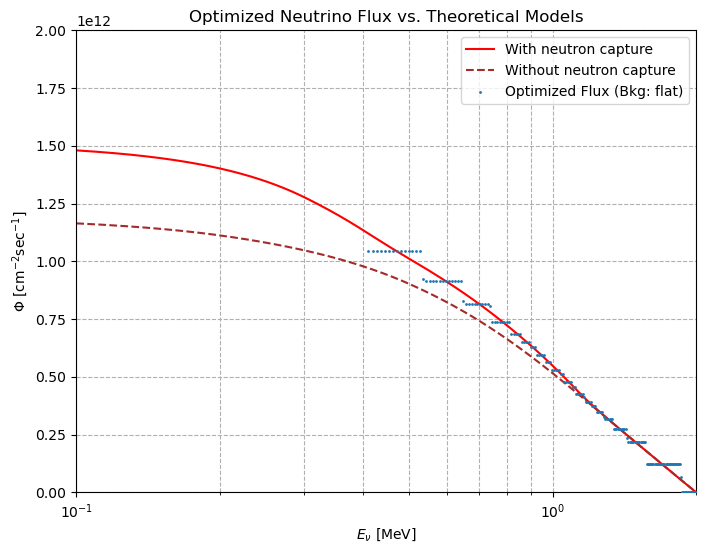

In [1]:
from neutrino_analysis_band import NeutrinoAnalysis

a = NeutrinoAnalysis(background_scenario='flat', intervals='180',
                     GeV=0.32e16, solver='osqp')
a.optimize(a.data_vector)   # Compute the best fit first (populates self.result)
result_flat = a.optimize(a.data_vector)
print("\nOptimization Complete.")
print(f"Minimum chi-squared: {result_flat.fun / a.c}")
# 3. Plot the primary result: the optimized flux vs. theory.
a.plot_flux_comparison(save = True)

## Save bands for several indices and overlay them

1. Run `find_and_save_band` per index and save one JSON file per index under `bands/`.
2. Load the saved files with `plot_flux_with_bands` and overlay each index's band as an error bar on top of the `optimize` flux scatter.

`save_band` / `load_band` use a human-readable JSON format. The band centre is the saved `self.result.x[index]`, so it lines up exactly with the scatter from the same `optimize` result.

In [ ]:
# Build bands for several indices and save one file per index
# Destination: ./bands/band_bkg<scenario>_idx<NNN>.json
indices = [0, 1, 2, 3, 4, 5, 8, 13, 16, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 167]     # Indices to run

for idx in indices:
    print(f'=== index {idx} ===')
    a.find_and_save_band(
        idx,
        outdir='scenario_bkg_flat/bands',
        levels=(0.678, 0.954),
        num_pseudo_data=50,
        n_pseudo_edge=500,
        step=1.5,
        rel_tol=0.03,
        seed=42,
        n_jobs=1,
        verbose=True,
    )

=== index 150 ===
[band idx=150] v0=1.2276e+11 (phys), bracketing with step=1.5
  upper bracket: 2.7621e+11
  lower edge reaches 0 / unbounded below
  level 0.678: [0.0000e+00, 2.2842e+11] (phys)
  level 0.954: [0.0000e+00, 2.6593e+11] (phys)
Band saved as scenario_bkg_flat/bands/band_bkgflat_idx150.json
=== index 160 ===
[band idx=160] v0=1.2276e+11 (phys), bracketing with step=1.5
  upper bracket: 2.7621e+11
  lower edge reaches 0 / unbounded below
  level 0.678: [0.0000e+00, 1.7729e+11] (phys)
  level 0.954: [0.0000e+00, 2.1170e+11] (phys)
Band saved as scenario_bkg_flat/bands/band_bkgflat_idx160.json
=== index 167 ===
[band idx=167] v0=0.0000e+00 (phys), bracketing with step=1.5
  upper edge unbounded (still inside at max_bracket)
  lower edge reaches 0 / unbounded below
  level 0.678: [0.0000e+00, inf] (phys)
  level 0.954: [0.0000e+00, inf] (phys)
Band saved as scenario_bkg_flat/bands/band_bkgflat_idx167.json


Plot saved as scenario_bkg_flat/flux_with_bands_bkg_flat.pdf


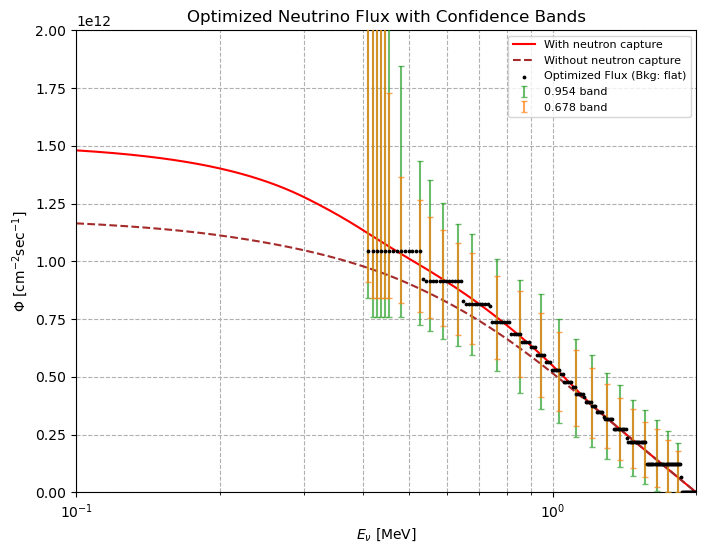

In [3]:
# Load the saved bands and overlay them on the optimize result
# band_files can be a glob pattern or an explicit list
a.plot_flux_with_bands(
    f'scenario_bkg_flat/bands/band_bkg{a.background_scenario}_idx*.json',
    levels=(0.678, 0.954),   # Levels to plot (omit to show all saved levels)
    save=True,
    ylim=(0, 3e13),                # So the high-flux tail is visible
)
import matplotlib.pyplot as plt
#plt.yscale('log')
plt.ylim(0, 2e12)
plt.show()

Plot saved as scenario_bkg_flat/flux_with_bands_bkg_flat.pdf


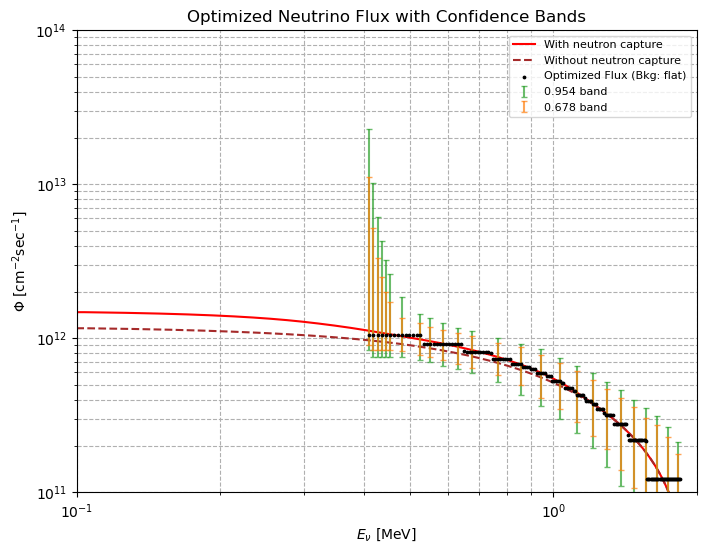

In [4]:
# Load the saved bands and overlay them on the optimize result
# band_files can be a glob pattern or an explicit list
a.plot_flux_with_bands(
    f'scenario_bkg_flat/bands/band_bkg{a.background_scenario}_idx*.json',
    levels=(0.678, 0.954),   # Levels to plot (omit to show all saved levels)
    save=True,
    ylim=(0, 3e13),                # So the high-flux tail is visible
)
import matplotlib.pyplot as plt
plt.yscale('log')
plt.ylim(1e11, 1e14)
plt.show()